# 📘 Session 21: Hyperparameter Tuning and Model Selection
### Duration: ~2.5–3 Hours

---

**Topics Covered:**
1. Parameters vs Hyperparameters
2. `GridSearchCV` — Systematic Search with Cross-Validation
3. Reading Grid Search Results (`best_params_`, `best_score_`, `cv_results_`)
4. `RandomizedSearchCV` — Faster Search over Large Spaces
5. Validation Curves — One Hyperparameter vs Score
6. Tuning Regression Models (Boston Housing)
7. Model Selection Workflow and Final Test Evaluation

---

**Why This Session Matters for Data Science:**
- Default models are rarely optimal — **tuning** improves performance
- **Cross-validation inside search** gives fair comparison of hyperparameter settings
- **Validation curves** show whether more complexity helps or hurts (bias–variance intuition)
- Proper workflow avoids **leaking test data** into tuning decisions

> **Prerequisites:** Sessions 17–20 (models, CV, regression, pipelines). Session 18 introduced CV; today we use CV **inside** hyperparameter search.

> **Not in this session:** Bayesian optimization, Optuna, AutoML platforms, neural network tuning.

**Libraries:** `pandas`, `numpy`, `seaborn`, `matplotlib`, **`scikit-learn`**


---
## 1. Parameters vs Hyperparameters

| Type | Set by | Learned from data? | Examples |
|------|--------|--------------------|----------|
| **Model parameters** | Training (`fit`) | Yes | Linear regression coefficients, tree splits |
| **Hyperparameters** | You (or search) | No | `n_estimators`, `max_depth`, `alpha`, `C` |

**Hyperparameter tuning** = trying combinations of hyperparameters and picking the best by **cross-validated** score.

### Tuning workflow (safe)

```
1. Train / test split (test locked away)
2. GridSearchCV on TRAIN only
3. Pick best hyperparameters from CV
4. Evaluate best pipeline ONCE on test
```

> ⚠️ **Special Case — never GridSearch on test labels**: If test rows influence hyperparameter choice, metrics are optimistically biased.

> **Data Science relevance**: Small grids (2–3 hyperparameters, few values each) often beat guessing defaults with modest compute cost.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, validation_curve,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, f1_score, r2_score, root_mean_squared_error


---
## 2. `GridSearchCV` — Classification (Penguins)

We search a **small grid** inside a **full pipeline** (preprocessor + `RandomForestClassifier`).

### Pipeline parameter naming

Use **`stepname__parameter`** syntax:

| Grid key | Meaning |
|----------|---------|
| `classifier__n_estimators` | Trees in the forest |
| `classifier__max_depth` | Max tree depth (`None` = expand until pure) |

`GridSearchCV` runs CV for **every combination** in the grid and picks the best mean score.


In [2]:
# --- Penguins setup ---
raw_pg = sns.load_dataset("penguins")
pg = raw_pg.dropna(
    subset=["species", "island", "sex", "bill_length_mm", "bill_depth_mm",
            "flipper_length_mm", "body_mass_g"]
).copy()
pg["bill_ratio"] = pg["bill_length_mm"] / pg["bill_depth_mm"]

y_pg = pg["species"]
X_pg = pg.drop(columns=["species"])
num_pg = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "bill_ratio"]
cat_pg = ["island", "sex"]

pre_pg = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), num_pg),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_pg),
])

clf_pipe = Pipeline([
    ("preprocessor", pre_pg),
    ("classifier", RandomForestClassifier(random_state=42)),
])

X_pg_train, X_pg_test, y_pg_train, y_pg_test = train_test_split(
    X_pg, y_pg, test_size=0.2, random_state=42, stratify=y_pg,
)

param_grid_clf = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_depth": [None, 5, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_clf = GridSearchCV(
    clf_pipe,
    param_grid=param_grid_clf,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True,
)

grid_clf.fit(X_pg_train, y_pg_train)

print("Best CV f1_macro:", grid_clf.best_score_.round(4))
print("Best params:", grid_clf.best_params_)


Best CV f1_macro: 0.9865
Best params: {'classifier__max_depth': None, 'classifier__n_estimators': 50}


---
## 3. Reading Grid Search Results

| Attribute | Meaning |
|-----------|---------|
| `best_params_` | Winning hyperparameter combination |
| `best_score_` | Mean CV score for best params |
| `best_estimator_` | Refitted pipeline on **full** `X_train` |
| `cv_results_` | Dict of all runs (scores, params, times) |

Use `cv_results_` to build a results table and see near-ties.


In [3]:
results_clf = pd.DataFrame(grid_clf.cv_results_)
cols = [
    "param_classifier__n_estimators",
    "param_classifier__max_depth",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]
print(results_clf[cols].sort_values("rank_test_score").head(6).to_string(index=False))

best_clf = grid_clf.best_estimator_
y_pg_pred = best_clf.predict(X_pg_test)
print(f"\nHold-out test accuracy: {accuracy_score(y_pg_test, y_pg_pred):.3f}")
print(f"Hold-out test f1_macro: {f1_score(y_pg_test, y_pg_pred, average='macro'):.3f}")


 param_classifier__n_estimators param_classifier__max_depth  mean_test_score  std_test_score  rank_test_score
                             50                        None         0.986492        0.011035                1
                            100                        None         0.986492        0.011035                1
                            200                        None         0.986492        0.011035                1
                             50                           5         0.986492        0.011035                1
                            100                           5         0.986492        0.011035                1
                            200                           5         0.986492        0.011035                1

Hold-out test accuracy: 1.000
Hold-out test f1_macro: 1.000


---
## 4. `RandomizedSearchCV` — When the Grid Is Too Large

**`RandomizedSearchCV`** samples random combinations from distributions instead of exhaustively visiting every cell.

| Use GridSearchCV when | Use RandomizedSearchCV when |
|-----------------------|----------------------------|
| Few hyperparameters, few values | Many hyperparameters or wide ranges |
| You want every combo scored | You have a compute budget (e.g. `n_iter=20`) |

Same pipeline naming rules apply (`classifier__...`).


In [4]:
from scipy.stats import randint

param_dist = {
    "classifier__n_estimators": randint(50, 300),
    "classifier__max_depth": [None, 4, 6, 8, 12],
}

rand_search = RandomizedSearchCV(
    clf_pipe,
    param_distributions=param_dist,
    n_iter=12,
    cv=cv,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1,
)
rand_search.fit(X_pg_train, y_pg_train)
print("RandomizedSearch best score:", rand_search.best_score_.round(4))
print("RandomizedSearch best params:", rand_search.best_params_)


RandomizedSearch best score: 0.9909
RandomizedSearch best params: {'classifier__max_depth': 8, 'classifier__n_estimators': 70}


---
## 5. Validation Curves — One Hyperparameter vs Score

**`validation_curve`** fixes all other settings and sweeps **one** hyperparameter. Plots help spot **overfitting** (train score keeps rising, validation stalls or drops).

```python
validation_curve(estimator, X, y, param_name=..., param_range=..., cv=...)
```

We sweep `classifier__n_estimators` on penguins (train split only).


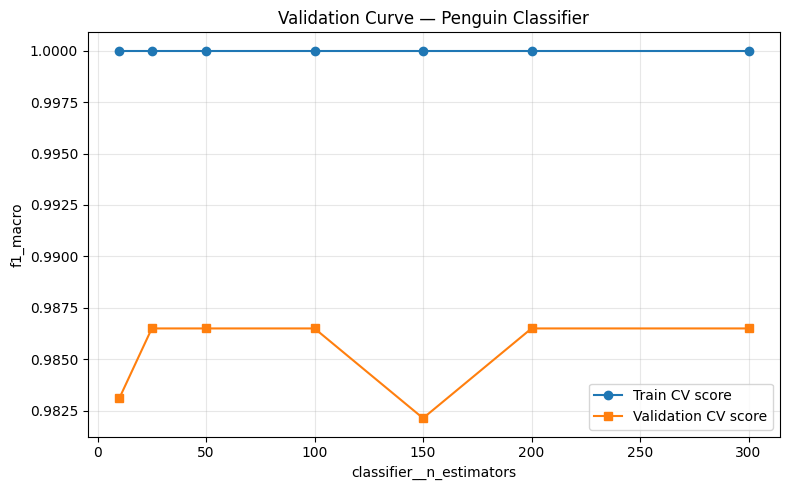

In [5]:
param_range = [10, 25, 50, 100, 150, 200, 300]
train_scores, val_scores = validation_curve(
    clf_pipe,
    X_pg_train,
    y_pg_train,
    param_name="classifier__n_estimators",
    param_range=param_range,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(param_range, train_mean, "o-", label="Train CV score")
plt.plot(param_range, val_mean, "s-", label="Validation CV score")
plt.xlabel("classifier__n_estimators")
plt.ylabel("f1_macro")
plt.title("Validation Curve — Penguin Classifier")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 6. Tuning Regression Models (Boston Housing)

Same pattern for **regression** with metrics like **`r2`** or **neg_root_mean_squared_error** (sklearn maximizes scores, so error metrics are often negated).

We tune **`Ridge` `alpha`** and compare a small **`RandomForestRegressor`** grid.


In [6]:
from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1, as_frame=True, parser="auto")
X_bo = boston.data
y_bo = boston.target.astype(float)

X_bo_train, X_bo_test, y_bo_train, y_bo_test = train_test_split(
    X_bo, y_bo, test_size=0.2, random_state=42,
)

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge()),
])

ridge_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
}

grid_ridge = GridSearchCV(
    ridge_pipe,
    param_grid=ridge_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
grid_ridge.fit(X_bo_train, y_bo_train)
print("Ridge best CV R2:", grid_ridge.best_score_.round(4))
print("Ridge best alpha:", grid_ridge.best_params_)

rf_reg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=42)),
])
rf_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 8, 16],
}
grid_rf = GridSearchCV(rf_reg_pipe, rf_grid, cv=5, scoring="r2", n_jobs=-1)
grid_rf.fit(X_bo_train, y_bo_train)
print("\nRF regressor best CV R2:", grid_rf.best_score_.round(4))
print("RF best params:", grid_rf.best_params_)


Ridge best CV R2: 0.7245
Ridge best alpha: {'model__alpha': 1.0}

RF regressor best CV R2: 0.8274
RF best params: {'model__max_depth': 16, 'model__n_estimators': 100}


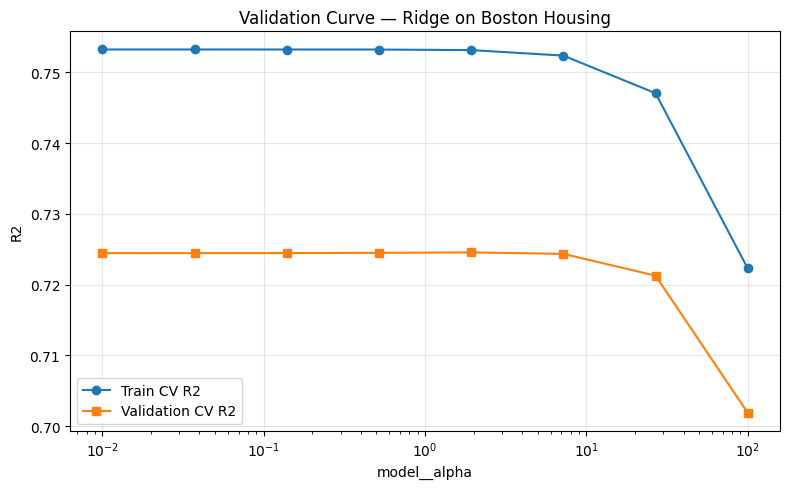

In [7]:
# Validation curve for Ridge alpha (Boston)
alphas = np.logspace(-2, 2, 8)
tr_r, val_r = validation_curve(
    ridge_pipe,
    X_bo_train,
    y_bo_train,
    param_name="model__alpha",
    param_range=alphas,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

plt.figure(figsize=(8, 5))
plt.semilogx(alphas, tr_r.mean(axis=1), "o-", label="Train CV R2")
plt.semilogx(alphas, val_r.mean(axis=1), "s-", label="Validation CV R2")
plt.xlabel("model__alpha")
plt.ylabel("R2")
plt.title("Validation Curve — Ridge on Boston Housing")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 7. Model Selection Workflow and Final Test Evaluation

| Step | Action |
|------|--------|
| 1 | Define metric aligned with business goal (`f1_macro`, `r2`, etc.) |
| 2 | `GridSearchCV` on **train** with pipeline |
| 3 | Compare candidates via `best_score_` and `cv_results_` |
| 4 | Optional: validation curve for interpretability |
| 5 | **Once**: evaluate `best_estimator_` on **hold-out test** |
| 6 | Session 20: save best pipeline with `joblib` |

### Hold-out comparison (this session)

| Task | Best model (CV) | Test metric |
|------|-----------------|-------------|
| Penguins classification | From `grid_clf` | accuracy / f1_macro |
| Boston regression | Pick ridge vs RF by CV R2 | test R2 / RMSE |


In [8]:
# Final test comparison — regression
best_ridge = grid_ridge.best_estimator_
best_rf = grid_rf.best_estimator_

for name, model in [("Ridge (tuned)", best_ridge), ("RF (tuned)", best_rf)]:
    pred = model.predict(X_bo_test)
    print(f"{name:16s}  R2={r2_score(y_bo_test, pred):.3f}  "
          f"RMSE={root_mean_squared_error(y_bo_test, pred):.3f}")

print("\nModel selection memo:")
print("- Classification: tune on train with stratified CV; report hold-out f1_macro")
print("- Regression: compare Ridge alpha grid vs RF depth grid by CV R2")
print("- Save winner with joblib (Session 20) after final test check")


Ridge (tuned)     R2=0.668  RMSE=4.931
RF (tuned)        R2=0.893  RMSE=2.802

Model selection memo:
- Classification: tune on train with stratified CV; report hold-out f1_macro
- Regression: compare Ridge alpha grid vs RF depth grid by CV R2
- Save winner with joblib (Session 20) after final test check


---
## 🧪 Practice Exercises

1. Add `classifier__min_samples_leaf` to the penguin grid (`[1, 2, 5]`). Does best score improve?
2. Run GridSearch with `scoring='accuracy'` vs `scoring='f1_macro'`. Do best params differ?
3. Plot `rank_test_score` vs `mean_test_score` for all ridge alphas from `grid_ridge.cv_results_`.
4. Use `RandomizedSearchCV` with `n_iter=30` on Boston RF regressor — beat the small grid?
5. Validation curve for `model__max_depth` on Boston RF (use a fixed `n_estimators=200`).
6. Why is sklearn scoring `neg_root_mean_squared_error` negated? Try it in `GridSearchCV` and interpret.
7. After tuning, save the best penguin pipeline to `models/penguins_tuned.joblib` (Session 20).
8. Write a 6-bullet memo: metric chosen, search method, best params, CV score, test score, deployment note.

---

## 📝 Session 21 Summary

| Topic | Key takeaway |
|-------|--------------|
| **Hyperparameters** | Chosen by search, not learned in `fit` |
| **GridSearchCV** | Exhaustive search + CV; use `step__param` for pipelines |
| **RandomizedSearchCV** | Sampled search when grid is large |
| **Validation curves** | Visualize one hyperparameter vs train/val score |
| **Regression tuning** | Same API; metrics like `r2` or negated RMSE |
| **Selection** | Tune on train; evaluate best model once on test |

### Key gotchas
- **Test set** must not drive hyperparameter picks
- Large grids explode runtime (`3 x 3` x 5 folds = 45 fits per metric)
- `best_score_` is **CV on train** — not the same as test score
- Always **`refit=True`** (default) to get `best_estimator_` trained on all training data
- More trees/depth can **overfit** — validation curves help you see it

### Next Session
**Session 22**: Unsupervised Learning and Clustering — K-Means, choosing K, silhouette score, and density-based clustering with DBSCAN.
